In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

print("imports good")

imports good


In [10]:
REEL_1 = ['M','M','M','M','M','M','W','W','W','W','W','C','C','C','C','D','D','S','S','B','B','B']
REEL_2 = ['M','M','M','M','M','M','W','W','W','W','W','C','C','C','C','D','D','S','S','B','B','B']
REEL_3 = ['M','M','M','M','M','M','W','W','W','W','W','C','C','C','C','D','D','S','S','B','B','B']

assert len(REEL_1) == 22
assert len(REEL_2) == 22
assert len(REEL_3) == 22

for name, reel in [("Reel 1", REEL_1), ("Reel 2", REEL_2), ("Reel 3", REEL_3)]:
    counts = pd.Series(reel).value_counts().sort_index()
    print(f"\n{name}:")
    for symbol, count in counts.items():
        print(f"  {symbol}: {count} stops ({count/22*100:.1f}%)")


Reel 1:
  B: 3 stops (13.6%)
  C: 4 stops (18.2%)
  D: 2 stops (9.1%)
  M: 6 stops (27.3%)
  S: 2 stops (9.1%)
  W: 5 stops (22.7%)

Reel 2:
  B: 3 stops (13.6%)
  C: 4 stops (18.2%)
  D: 2 stops (9.1%)
  M: 6 stops (27.3%)
  S: 2 stops (9.1%)
  W: 5 stops (22.7%)

Reel 3:
  B: 3 stops (13.6%)
  C: 4 stops (18.2%)
  D: 2 stops (9.1%)
  M: 6 stops (27.3%)
  S: 2 stops (9.1%)
  W: 5 stops (22.7%)


In [11]:
# Total stops per reel
TOTAL = 22

# Stop counts
stops = {
    'M': 6, 'W': 5, 'C': 4, 'D': 2, 'S': 2, 'B': 3
}

# Three of a kind probabilities (all 3 reels match)
def three_of_a_kind_prob(symbol):
    n = stops[symbol]
    return (n/TOTAL) ** 3

# Two of a kind probability (reels 1 and 2 match, reel 3 does NOT match)
def two_of_a_kind_prob(symbol):
    n = stops[symbol]
    not_n = TOTAL - n
    return (n/TOTAL) * (n/TOTAL) * (not_n/TOTAL)

# Bonus trigger: all 3 Straw Hats anywhere (same as three of a kind for S)
bonus_prob = three_of_a_kind_prob('S')

print("=== WIN PROBABILITIES ===\n")
print(f"Three Meat:          {three_of_a_kind_prob('M')*100:.4f}%")
print(f"Three Wanted Poster: {three_of_a_kind_prob('W')*100:.4f}%")
print(f"Three Chest:         {three_of_a_kind_prob('C')*100:.4f}%")
print(f"Three Devil Fruit:   {three_of_a_kind_prob('D')*100:.4f}%")
print(f"Three Straw Hat:     {three_of_a_kind_prob('S')*100:.4f}% (bonus trigger)")
print(f"\nTwo Meat:            {two_of_a_kind_prob('M')*100:.4f}%")
print(f"Two Wanted Poster:   {two_of_a_kind_prob('W')*100:.4f}%")

print(f"\n=== HIT FREQUENCY ===")
total_hit = (
    three_of_a_kind_prob('M') +
    three_of_a_kind_prob('W') +
    three_of_a_kind_prob('C') +
    three_of_a_kind_prob('D') +
    three_of_a_kind_prob('S') +
    two_of_a_kind_prob('M') +
    two_of_a_kind_prob('W')
)
print(f"Total hit frequency: {total_hit*100:.2f}%")
print(f"One win every {1/total_hit:.1f} spins on average")

=== WIN PROBABILITIES ===

Three Meat:          2.0285%
Three Wanted Poster: 1.1739%
Three Chest:         0.6011%
Three Devil Fruit:   0.0751%
Three Straw Hat:     0.0751% (bonus trigger)

Two Meat:            5.4095%
Two Wanted Poster:   3.9914%

=== HIT FREQUENCY ===
Total hit frequency: 13.35%
One win every 7.5 spins on average


In [12]:
# Bonus contribution calculation
# Average chest pool: 4x(2x) + 3x(3x) + 2x(5x) = 8+9+10 = 27 total / 9 chests = 3x per pick
# Player picks 3 chests so average bonus payout = 3 * 3 = 9x the bet
BONUS_AVG_PAYOUT = 9
bonus_rtp = three_of_a_kind_prob('S') * BONUS_AVG_PAYOUT
print(f"Bonus RTP contribution: {bonus_rtp*100:.4f}%")

# Remaining RTP budget for base game
TARGET_RTP = 0.90
base_rtp_budget = TARGET_RTP - bonus_rtp
print(f"Base game RTP budget:   {base_rtp_budget*100:.4f}%")

# Now solve for paytable multipliers
# RTP contribution of each combination = probability * multiplier
# We need all contributions to sum to base_rtp_budget

# Known probabilities
p = {
    '3M': three_of_a_kind_prob('M'),
    '3W': three_of_a_kind_prob('W'),
    '3C': three_of_a_kind_prob('C'),
    '3D': three_of_a_kind_prob('D'),
    '2M': two_of_a_kind_prob('M'),
    '2W': two_of_a_kind_prob('W'),
}

# Strategy: assign multipliers that feel right for the symbol tier
# then calculate what RTP they produce
# Two of a kind pays 2x (return bet plus small profit)
# Three of a kind scales up by tier

paytable = {
    '3M': 5,    # Three Meat
    '3W': 10,   # Three Wanted Poster
    '3C': 25,   # Three Chest
    '3D': 150,  # Three Devil Fruit
    '2M': 2,    # Two Meat
    '2W': 2,    # Two Wanted Poster
}

def calculate_rtp(paytable, p, bonus_rtp):
    base = sum(paytable[k] * p[k] for k in paytable)
    total = base + bonus_rtp
    return base, total

base, total = calculate_rtp(paytable, p, bonus_rtp)

print(f"\n=== PAYTABLE v1 ===")
print(f"{'Combination':<25} {'Multiplier':>10} {'Probability':>12} {'RTP Contribution':>18}")
print("-" * 70)
for k, mult in paytable.items():
    print(f"{k:<25} {mult:>10}x {p[k]*100:>11.4f}% {p[k]*mult*100:>17.4f}%")
print(f"\n{'Bonus trigger':<25} {'9':>10}x {three_of_a_kind_prob('S')*100:>11.4f}% {bonus_rtp*100:>17.4f}%")
print("-" * 70)
print(f"{'Base game RTP':<25} {base*100:>52.4f}%")
print(f"{'Total RTP':<25} {total*100:>52.4f}%")
print(f"\nTarget: 90.00%")
print(f"Delta:  {(total - TARGET_RTP)*100:+.4f}%")

Bonus RTP contribution: 0.6762%
Base game RTP budget:   89.3238%

=== PAYTABLE v1 ===
Combination               Multiplier  Probability   RTP Contribution
----------------------------------------------------------------------
3M                                 5x      2.0285%           10.1427%
3W                                10x      1.1739%           11.7393%
3C                                25x      0.6011%           15.0263%
3D                               150x      0.0751%           11.2697%
2M                                 2x      5.4095%           10.8189%
2W                                 2x      3.9914%            7.9827%

Bonus trigger                      9x      0.0751%            0.6762%
----------------------------------------------------------------------
Base game RTP                                                          66.9797%
Total RTP                                                              67.6559%

Target: 90.00%
Delta:  -22.3441%


In [13]:
# We need 89.32% from base game
# Current base = 66.98%, gap = 22.34%
# Strategy: scale up all multipliers proportionally then fine tune

# Scale factor starting point
# 89.32 / 66.98 = 1.333, so we need roughly 1.33x all multipliers
# But two of a kind at 2x cant go much higher without feeling wrong
# So we push the weight onto three of a kind multipliers

paytable_v2 = {
    '3M': 8,     # Three Meat: common so moderate multiplier
    '3W': 15,    # Three Wanted Poster
    '3C': 40,    # Three Chest: mid tier bump
    '3D': 250,   # Three Devil Fruit: rare so high payout
    '2M': 3,     # Two Meat: slight bump
    '2W': 3,     # Two Wanted Poster: slight bump
}

base_v2, total_v2 = calculate_rtp(paytable_v2, p, bonus_rtp)

print(f"=== PAYTABLE v2 ===")
print(f"{'Combination':<25} {'Multiplier':>10} {'Probability':>12} {'RTP Contribution':>18}")
print("-" * 70)
for k, mult in paytable_v2.items():
    print(f"{k:<25} {mult:>10}x {p[k]*100:>11.4f}% {p[k]*mult*100:>17.4f}%")
print(f"\n{'Bonus trigger':<25} {'9':>10}x {three_of_a_kind_prob('S')*100:>11.4f}% {bonus_rtp*100:>17.4f}%")
print("-" * 70)
print(f"{'Base game RTP':<25} {base_v2*100:>52.4f}%")
print(f"{'Total RTP':<25} {total_v2*100:>52.4f}%")
print(f"\nTarget: 90.00%")
print(f"Delta:  {(total_v2 - TARGET_RTP)*100:+.4f}%")

# Also run an iterative solver to find the exact Devil Fruit multiplier
# that closes the remaining gap, keeping all other multipliers fixed
print(f"\n=== SOLVER: Finding exact 3D multiplier to hit 90% ===")

fixed_rtp = (
    paytable_v2['3M'] * p['3M'] +
    paytable_v2['3W'] * p['3W'] +
    paytable_v2['3C'] * p['3C'] +
    paytable_v2['2M'] * p['2M'] +
    paytable_v2['2W'] * p['2W'] +
    bonus_rtp
)

remaining = TARGET_RTP - fixed_rtp
exact_3D = remaining / p['3D']
print(f"Fixed RTP from all other combinations: {fixed_rtp*100:.4f}%")
print(f"Remaining budget for 3D:               {remaining*100:.4f}%")
print(f"Exact 3D multiplier needed:            {exact_3D:.2f}x")
print(f"Rounded to nearest 5:                  {round(exact_3D/5)*5}x")

=== PAYTABLE v2 ===
Combination               Multiplier  Probability   RTP Contribution
----------------------------------------------------------------------
3M                                 8x      2.0285%           16.2284%
3W                                15x      1.1739%           17.6089%
3C                                40x      0.6011%           24.0421%
3D                               250x      0.0751%           18.7829%
2M                                 3x      5.4095%           16.2284%
2W                                 3x      3.9914%           11.9741%

Bonus trigger                      9x      0.0751%            0.6762%
----------------------------------------------------------------------
Base game RTP                                                         104.8648%
Total RTP                                                             105.5409%

Target: 90.00%
Delta:  +15.5409%

=== SOLVER: Finding exact 3D multiplier to hit 90% ===
Fixed RTP from all other com

In [14]:
# Final paytable using solver result
paytable_final = {
    '3M': 8,    # Three Meat
    '3W': 15,   # Three Wanted Poster
    '3C': 40,   # Three Chest
    '3D': 45,   # Three Devil Fruit (solver result)
    '2M': 3,    # Two Meat
    '2W': 3,    # Two Wanted Poster
}

base_final, total_final = calculate_rtp(paytable_final, p, bonus_rtp)

print(f"=== FINAL PAYTABLE ===")
print(f"{'Combination':<25} {'Multiplier':>10} {'Payout ($0.01 bet)':>20} {'Probability':>12} {'RTP Contribution':>18}")
print("-" * 90)
for k, mult in paytable_final.items():
    payout = mult * 0.01
    print(f"{k:<25} {mult:>10}x {f'${payout:.2f}':>20} {p[k]*100:>11.4f}% {p[k]*mult*100:>17.4f}%")

bonus_payout = 9 * 0.01
print(f"\n{'Bonus trigger':<25} {'avg 9':>10}x {f'${bonus_payout:.2f} avg':>20} {three_of_a_kind_prob('S')*100:>11.4f}% {bonus_rtp*100:>17.4f}%")
print("-" * 90)
print(f"{'Base game RTP':<25} {base_final*100:>72.4f}%")
print(f"{'Total RTP':<25} {total_final*100:>72.4f}%")
print(f"\nTarget:    90.00%")
print(f"Actual:    {total_final*100:.4f}%")
print(f"Delta:     {(total_final - TARGET_RTP)*100:+.4f}%")
print(f"\nHit frequency: {total_hit*100:.2f}% (one win every {1/total_hit:.1f} spins)")
print(f"Cost per spin: $0.01")
print(f"EV per spin:   ${total_final * 0.01:.4f}")
print(f"House edge:    {(1-total_final)*100:.4f}%")

=== FINAL PAYTABLE ===
Combination               Multiplier   Payout ($0.01 bet)  Probability   RTP Contribution
------------------------------------------------------------------------------------------
3M                                 8x                $0.08      2.0285%           16.2284%
3W                                15x                $0.15      1.1739%           17.6089%
3C                                40x                $0.40      0.6011%           24.0421%
3D                                45x                $0.45      0.0751%            3.3809%
2M                                 3x                $0.03      5.4095%           16.2284%
2W                                 3x                $0.03      3.9914%           11.9741%

Bonus trigger                  avg 9x            $0.09 avg      0.0751%            0.6762%
------------------------------------------------------------------------------------------
Base game RTP                                                      

In [25]:
np.random.seed(42)

NUM_SPINS = 1000
DENOMINATION = 1.00
BET_LEVELS = [1, 3, 5]
BET = DENOMINATION * BET_LEVELS[0]  # Default to 1x bet ($1.00)
starting_bankroll = 100.00

bankroll = starting_bankroll
bankroll_history = [bankroll]
win_amounts = []
spin_results = []

for spin in range(NUM_SPINS):
    if bankroll < BET:
        print(f"Bankroll depleted at spin {spin}. Stopping simulation.")
        break
    r1 = np.random.choice(REEL_1)
    r1 = np.random.choice(REEL_1)
    r2 = np.random.choice(REEL_2)
    r3 = np.random.choice(REEL_3)
    
    bankroll -= BET
    win = 0
    result_type = 'loss'
    
    # Check bonus trigger first
    if r1 == 'S' and r2 == 'S' and r3 == 'S':
        chest_pool = [2,2,2,2,3,3,3,5,5]
        picks = np.random.choice(chest_pool, size=3, replace=False)
        win = sum(picks) * BET
        result_type = 'bonus'
    
    # Three of a kind
    elif r1 == r2 == r3 == 'M':
        win = paytable_final['3M'] * BET
        result_type = '3M'
    elif r1 == r2 == r3 == 'W':
        win = paytable_final['3W'] * BET
        result_type = '3W'
    elif r1 == r2 == r3 == 'C':
        win = paytable_final['3C'] * BET
        result_type = '3C'
    elif r1 == r2 == r3 == 'D':
        win = paytable_final['3D'] * BET
        result_type = '3D'
    
    # Two of a kind (reels 1 and 2 only)
    elif r1 == r2 == 'M' and r3 != 'M':
        win = paytable_final['2M'] * BET
        result_type = '2M'
    elif r1 == r2 == 'W' and r3 != 'W':
        win = paytable_final['2W'] * BET
        result_type = '2W'
    
    bankroll += win
    bankroll_history.append(bankroll)
    win_amounts.append(win)
    spin_results.append({
        'spin': spin + 1,
        'r1': r1, 'r2': r2, 'r3': r3,
        'result': result_type,
        'win': win,
        'bankroll': bankroll
    })

df = pd.DataFrame(spin_results)

# Summary stats
total_wagered = NUM_SPINS * BET
total_won = df['win'].sum()
realized_rtp = total_won / total_wagered
wins_only = df[df['win'] > 0]
losses = df[df['win'] == 0]

print(f"=== 1000 SPIN SIMULATION RESULTS ===\n")
print(f"Denomination:       ${DENOMINATION:.2f}")
print(f"Bet size (1x):      ${BET:.2f}")
print(f"Bet sizes available: {['$'+str(int(DENOMINATION*b)) for b in BET_LEVELS]}")
print(f"Starting bankroll:  ${starting_bankroll:.2f}")
print(f"Ending bankroll:    ${bankroll:.2f}")
print(f"Total wagered:      ${total_wagered:.2f}")
print(f"Total returned:     ${total_won:.2f}")
print(f"Realized RTP:       {realized_rtp*100:.2f}%")
print(f"Theoretical RTP:    90.14%")
print(f"\n=== WIN BREAKDOWN ===")
print(df[df['win']>0]['result'].value_counts().to_string())
print(f"\n=== PAYOUT REFERENCE (all bet levels) ===")
payouts = {
    'Three Meat':    [paytable_final['3M']*DENOMINATION*b for b in BET_LEVELS],
    'Three Wanted':  [paytable_final['3W']*DENOMINATION*b for b in BET_LEVELS],
    'Three Chest':   [paytable_final['3C']*DENOMINATION*b for b in BET_LEVELS],
    'Three Devil':   [paytable_final['3D']*DENOMINATION*b for b in BET_LEVELS],
    'Two Meat':      [paytable_final['2M']*DENOMINATION*b for b in BET_LEVELS],
    'Two Wanted':    [paytable_final['2W']*DENOMINATION*b for b in BET_LEVELS],
}
print(f"{'Combination':<20} {'$1 bet':>10} {'$3 bet':>10} {'$5 bet':>10}")
print("-" * 52)
for name, pays in payouts.items():
    print(f"{name:<20} {'$'+str(pays[0]):>10} {'$'+str(pays[1]):>10} {'$'+str(pays[2]):>10}")
print(f"\n=== DRY SPELL ANALYSIS ===")

max_dry = 0
current_dry = 0
dry_spells = []
for w in win_amounts:
    if w == 0:
        current_dry += 1
        max_dry = max(max_dry, current_dry)
    else:
        if current_dry > 0:
            dry_spells.append(current_dry)
        current_dry = 0

print(f"Longest dry spell:  {max_dry} spins")
print(f"Average dry spell:  {np.mean(dry_spells):.1f} spins")
print(f"Total winning spins: {len(wins_only)} of {NUM_SPINS} ({len(wins_only)/NUM_SPINS*100:.1f}%)")

=== 1000 SPIN SIMULATION RESULTS ===

Denomination:       $1.00
Bet size (1x):      $1.00
Bet sizes available: ['$1', '$3', '$5']
Starting bankroll:  $100.00
Ending bankroll:    $147.00
Total wagered:      $1000.00
Total returned:     $1047.00
Realized RTP:       104.70%
Theoretical RTP:    90.14%

=== WIN BREAKDOWN ===
result
2M       59
2W       33
3M       23
3W       13
3C        7
3D        2
bonus     2

=== PAYOUT REFERENCE (all bet levels) ===
Combination              $1 bet     $3 bet     $5 bet
----------------------------------------------------
Three Meat                 $8.0      $24.0      $40.0
Three Wanted              $15.0      $45.0      $75.0
Three Chest               $40.0     $120.0     $200.0
Three Devil               $45.0     $135.0     $225.0
Two Meat                   $3.0       $9.0      $15.0
Two Wanted                 $3.0       $9.0      $15.0

=== DRY SPELL ANALYSIS ===
Longest dry spell:  29 spins
Average dry spell:  7.4 spins
Total winning spins: 139 o

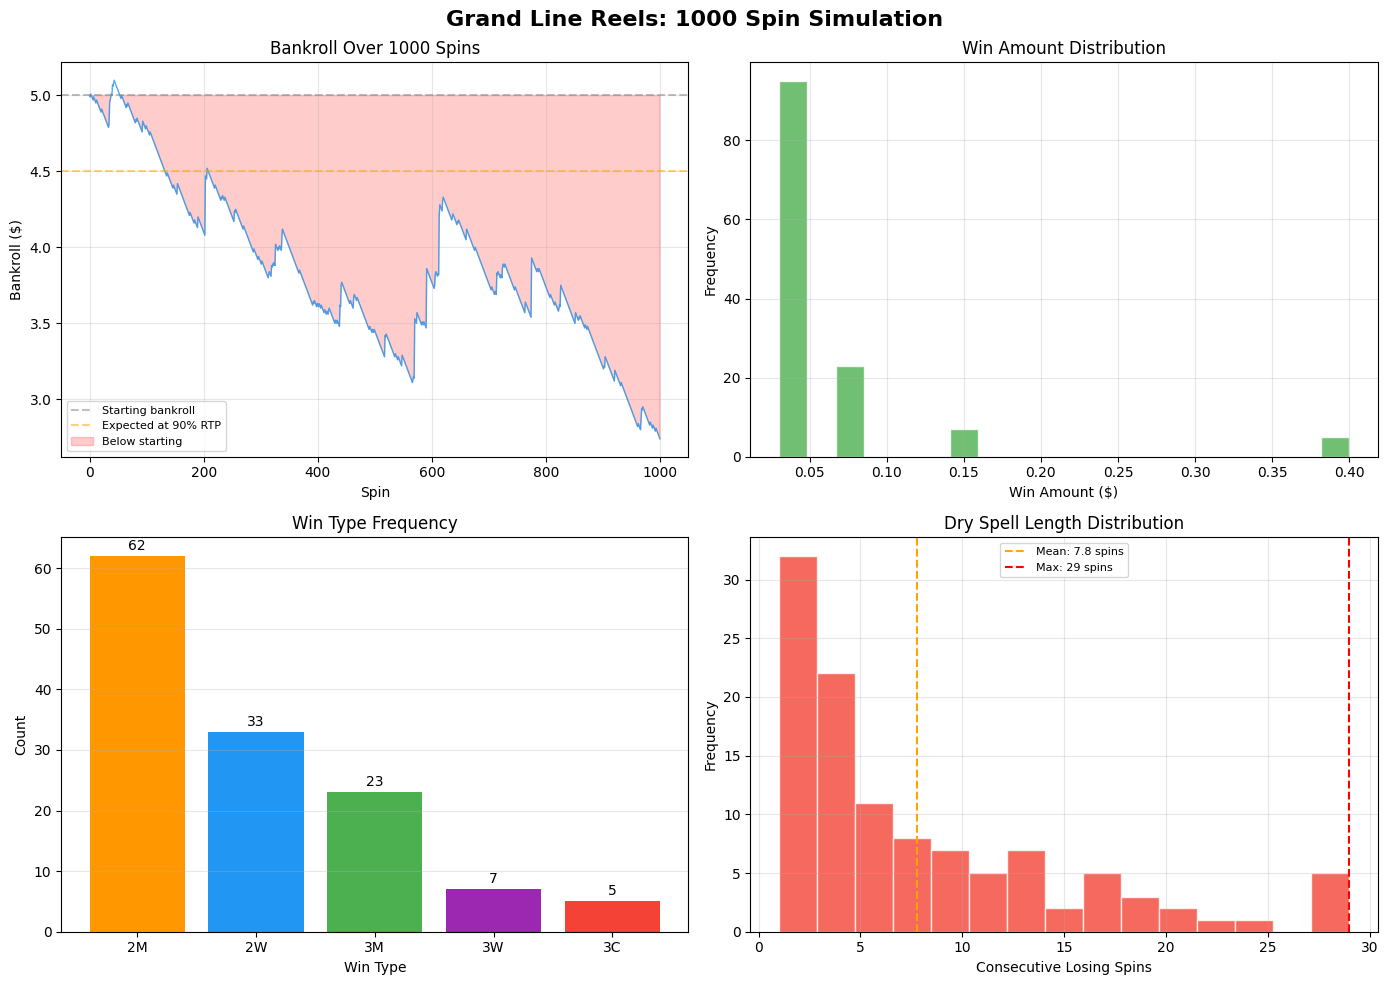

Charts saved to docs/simulation_charts.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Grand Line Reels: 1000 Spin Simulation', fontsize=16, fontweight='bold')

# Chart 1: Bankroll over time
ax1 = axes[0, 0]
ax1.plot(bankroll_history, color='#2196F3', linewidth=1, alpha=0.8)
ax1.axhline(y=starting_bankroll, color='gray', linestyle='--', alpha=0.5, label='Starting bankroll')
ax1.axhline(y=starting_bankroll * TARGET_RTP, color='orange', linestyle='--', alpha=0.5, label='Expected at 90% RTP')
ax1.fill_between(range(len(bankroll_history)), bankroll_history, starting_bankroll, 
                  where=[b < starting_bankroll for b in bankroll_history],
                  alpha=0.2, color='red', label='Below starting')
ax1.set_title('Bankroll Over 1000 Spins')
ax1.set_xlabel('Spin')
ax1.set_ylabel('Bankroll ($)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Chart 2: Win distribution histogram
ax2 = axes[0, 1]
wins_nonzero = df[df['win'] > 0]['win']
win_labels = {0.03: '2x ($0.03)', 0.08: '3M ($0.08)', 0.15: '3W ($0.15)', 
              0.40: '3C ($0.40)', 0.45: '3D ($0.45)'}
ax2.hist(wins_nonzero, bins=20, color='#4CAF50', edgecolor='white', alpha=0.8)
ax2.set_title('Win Amount Distribution')
ax2.set_xlabel('Win Amount ($)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)

# Chart 3: Win type breakdown
ax3 = axes[1, 0]
win_counts = df[df['win'] > 0]['result'].value_counts()
colors = ['#FF9800', '#2196F3', '#4CAF50', '#9C27B0', '#F44336', '#00BCD4']
bars = ax3.bar(win_counts.index, win_counts.values, color=colors[:len(win_counts)])
ax3.set_title('Win Type Frequency')
ax3.set_xlabel('Win Type')
ax3.set_ylabel('Count')
for bar, val in zip(bars, win_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(val), ha='center', va='bottom', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Chart 4: Dry spell distribution
ax4 = axes[1, 1]
ax4.hist(dry_spells, bins=15, color='#F44336', edgecolor='white', alpha=0.8)
ax4.axvline(x=np.mean(dry_spells), color='orange', linestyle='--', 
            label=f'Mean: {np.mean(dry_spells):.1f} spins')
ax4.axvline(x=max_dry, color='red', linestyle='--', 
            label=f'Max: {max_dry} spins')
ax4.set_title('Dry Spell Length Distribution')
ax4.set_xlabel('Consecutive Losing Spins')
ax4.set_ylabel('Frequency')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/simulation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved to docs/simulation_charts.png")

In [18]:
DENOMINATION = 1.00
BET_LEVELS = [1, 3, 5]

config = {
    "game": {
        "name": "Grand Line Reels",
        "theme": "One Piece",
        "denomination": DENOMINATION,
        "bet_levels": BET_LEVELS,
        "default_bet": 1,
        "starting_bankroll": 100.00,
        "reels": 3,
        "stops_per_reel": 22,
        "paylines": 1,
        "display": "3x3"
    },
    "reel_strips": {
        "reel_1": REEL_1,
        "reel_2": REEL_2,
        "reel_3": REEL_3
    },
    "paytable": {
        "3M": {
            "multiplier": 8,
            "payout_1x": round(8 * DENOMINATION * 1, 2),
            "payout_3x": round(8 * DENOMINATION * 3, 2),
            "payout_5x": round(8 * DENOMINATION * 5, 2),
            "description": "Three Meat"
        },
        "3W": {
            "multiplier": 15,
            "payout_1x": round(15 * DENOMINATION * 1, 2),
            "payout_3x": round(15 * DENOMINATION * 3, 2),
            "payout_5x": round(15 * DENOMINATION * 5, 2),
            "description": "Three Wanted Poster"
        },
        "3C": {
            "multiplier": 40,
            "payout_1x": round(40 * DENOMINATION * 1, 2),
            "payout_3x": round(40 * DENOMINATION * 3, 2),
            "payout_5x": round(40 * DENOMINATION * 5, 2),
            "description": "Three Treasure Chest"
        },
        "3D": {
            "multiplier": 45,
            "payout_1x": round(45 * DENOMINATION * 1, 2),
            "payout_3x": round(45 * DENOMINATION * 3, 2),
            "payout_5x": round(45 * DENOMINATION * 5, 2),
            "description": "Three Devil Fruit"
        },
        "2M": {
            "multiplier": 3,
            "payout_1x": round(3 * DENOMINATION * 1, 2),
            "payout_3x": round(3 * DENOMINATION * 3, 2),
            "payout_5x": round(3 * DENOMINATION * 5, 2),
            "description": "Two Meat"
        },
        "2W": {
            "multiplier": 3,
            "payout_1x": round(3 * DENOMINATION * 1, 2),
            "payout_3x": round(3 * DENOMINATION * 3, 2),
            "payout_5x": round(3 * DENOMINATION * 5, 2),
            "description": "Two Wanted Poster"
        }
    },
    "bonus": {
        "trigger": "Three Straw Hats anywhere",
        "trigger_probability": round(bonus_prob, 6),
        "feature": "Treasure Hunt",
        "structure": "Pick 3 of 9 chests",
        "chest_pool": [2, 2, 2, 2, 3, 3, 3, 5, 5],
        "average_payout_multiplier": 9,
        "average_payout_1x": round(9 * DENOMINATION * 1, 2),
        "average_payout_3x": round(9 * DENOMINATION * 3, 2),
        "average_payout_5x": round(9 * DENOMINATION * 5, 2)
    },
    "math": {
        "theoretical_rtp": round(total_final, 6),
        "theoretical_rtp_pct": round(total_final * 100, 4),
        "hit_frequency": round(total_hit, 6),
        "hit_frequency_pct": round(total_hit * 100, 4),
        "ev_per_spin_1x": round(total_final * DENOMINATION * 1, 6),
        "ev_per_spin_3x": round(total_final * DENOMINATION * 3, 6),
        "ev_per_spin_5x": round(total_final * DENOMINATION * 5, 6),
        "house_edge_pct": round((1 - total_final) * 100, 4),
        "simulation_spins": NUM_SPINS,
        "simulation_rtp_pct": round(realized_rtp * 100, 4),
        "longest_dry_spell": int(max_dry),
        "average_dry_spell": round(float(np.mean(dry_spells)), 2)
    }
}

with open('../config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("config.json exported successfully")
print(f"\nDenomination: ${DENOMINATION}")
print(f"Bet levels: {['$'+str(DENOMINATION*b) for b in BET_LEVELS]}")
print(f"\nFile contents preview:")
print(json.dumps(config['math'], indent=2))

config.json exported successfully

Denomination: $1.0
Bet levels: ['$1.0', '$3.0', '$5.0']

File contents preview:
{
  "theoretical_rtp": 0.90139,
  "theoretical_rtp_pct": 90.139,
  "hit_frequency": 0.133546,
  "hit_frequency_pct": 13.3546,
  "ev_per_spin_1x": 0.90139,
  "ev_per_spin_3x": 2.70417,
  "ev_per_spin_5x": 4.50695,
  "house_edge_pct": 9.861,
  "simulation_spins": 1000,
  "simulation_rtp_pct": 77.4,
  "longest_dry_spell": 29,
  "average_dry_spell": 7.77
}
